# 02 - Local Baseline CNN Training

This notebook trains the custom baseline CNN locally using the split CSV files generated by `01_eda.ipynb`. It saves the best model and baseline evaluation artifacts.


## 1. Project setup


In [2]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError(f"Could not find src/ from current directory: {NOTEBOOK_DIR}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: d:\UWE\3rd Year\2nd semester\advanced_ai\ai_system


## 2. Imports and configuration


In [3]:
import json
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay

from src.config import (
    CLASS_NAMES_PATH,
    CM_DIR,
    FIGURES_DIR,
    IMAGE_SIZE,
    MODEL_METADATA_PATH,
    MODELS_DIR,
    NUM_CLASSES,
    RANDOM_SEED,
    SPLITS_DIR,
)
from src.data.dataloaders import build_class_name_mapping, make_dataset_from_dataframe
from src.models.baseline_cnn import build_baseline_cnn
from src.train.evaluate import evaluate_model
from src.train.train import compile_model, train_model

tf.keras.utils.set_random_seed(RANDOM_SEED)
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.21.0
GPUs: []


## 3. Load split files


In [4]:
train_csv = SPLITS_DIR / "train.csv"
val_csv = SPLITS_DIR / "val.csv"
test_csv = SPLITS_DIR / "test.csv"

for path in [train_csv, val_csv, test_csv, CLASS_NAMES_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}. Run 01_eda.ipynb first.")

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names = json.load(f)

class_to_index = {name: idx for idx, name in enumerate(class_names)}

print(len(train_df), len(val_df), len(test_df))
print("Classes:", len(class_names))
assert len(class_names) == NUM_CLASSES


20493 4392 4392
Classes: 28


## 4. Build TensorFlow datasets


In [5]:
train_ds = make_dataset_from_dataframe(train_df, class_to_index, training=True)
val_ds = make_dataset_from_dataframe(val_df, class_to_index, training=False)
test_ds = make_dataset_from_dataframe(test_df, class_to_index, training=False)

for images, labels in train_ds.take(1):
    print("Image batch:", images.shape)
    print("Label batch:", labels.shape)


Image batch: (32, 224, 224, 3)
Label batch: (32,)


## 5. Build and train baseline CNN


In [6]:
EPOCHS = 10
LEARNING_RATE = 1e-3

MODELS_DIR.mkdir(parents=True, exist_ok=True)
checkpoint_path = MODELS_DIR / "baseline_cnn_best.keras"

model = build_baseline_cnn(num_classes=NUM_CLASSES)
model = compile_model(model, learning_rate=LEARNING_RATE)
model.summary()

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=EPOCHS,
    checkpoint_path=checkpoint_path,
)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,860 (378.36 KB)

 Trainable params: 96,860 (378.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 264s 408ms/step - accuracy: 0.2577 - loss: 2.4343 - val_accuracy: 0.4003 - val_loss: 1.8887 - learning_rate: 0.0010
Epoch 2/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 250s 389ms/step - accuracy: 0.4381 - loss: 1.8435 - val_accuracy: 0.4656 - val_loss: 1.7154 - learning_rate: 0.0010
Epoch 3/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 255s 396ms/step - accuracy: 0.5177 - loss: 1.6171 - val_accuracy: 0.5947 - val_loss: 1.3908 - learning_rate: 0.0010
Epoch 4/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 251s 390ms/step - accuracy: 0.5770 - loss: 1.4448 - val_accuracy: 0.6366 - val_loss: 1.2787 - learning_rate: 0.0010
Epoch 5/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 244s 379ms/step - accuracy: 0.6122 - loss: 1.3253 - val_accuracy: 0.6662 - val_loss: 1.1424 - learning_rate: 0.0010
Epoch 6/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 244s 379ms/step - accuracy: 0.6408 - loss: 1.2298 - val_accuracy: 0.6926 - val_loss: 1.0745 - learning_rate: 0.0010
Epoch 7/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 246s 384ms/step - accura

## 6. Training curves


,accuracy,loss,val_accuracy,val_loss,learning_rate
5,0.640804,1.229754,0.692623,1.074494,0.001
6,0.667106,1.161659,0.718124,1.018564,0.001
7,0.676719,1.099538,0.727231,0.956258,0.001
8,0.692724,1.045135,0.744536,0.886543,0.001
9,0.708632,0.995770,0.745902,0.857029,0.001


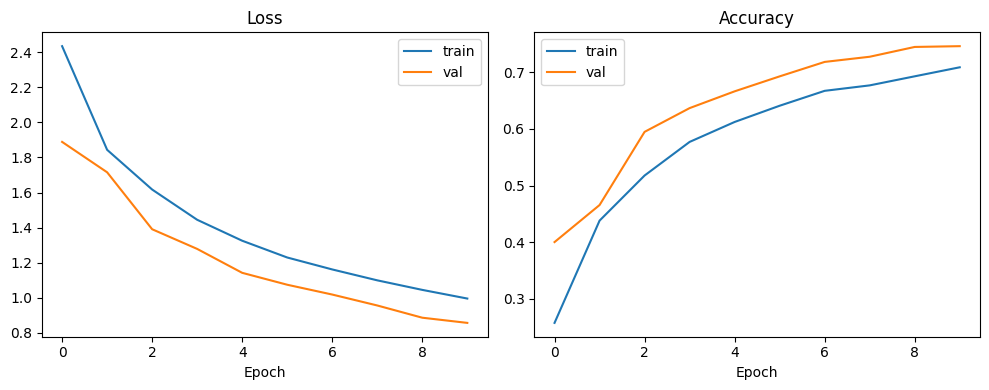

In [7]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

history_df = pd.DataFrame(history.history)
display(history_df.tail())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_df["loss"], label="train")
plt.plot(history_df["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["accuracy"], label="train")
plt.plot(history_df["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_cnn_training_curves.png", dpi=150)
plt.show()


## 7. Evaluate on test set


In [8]:
results = evaluate_model(model, test_ds, class_names)
report = results["classification_report"]
cm = results["confusion_matrix"]

report_df = pd.DataFrame(report).transpose()
display(report_df)

accuracy = float(report["accuracy"])
macro_f1 = float(report["macro avg"]["f1-score"])
print("Test accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))


,precision,recall,f1-score,support
Apple__Healthy,0.806971,0.824658,0.815718,365.000000
Apple__Rotten,0.767442,0.676538,0.719128,439.000000
Banana__Healthy,0.742029,0.853333,0.793798,300.000000
Banana__Rotten,0.772000,0.921241,0.840044,419.000000
Bellpepper__Healthy,0.858824,0.793478,0.824859,92.000000
Bellpepper__Rotten,0.456140,0.292135,0.356164,89.000000
Carrot__Healthy,0.831169,0.688172,0.752941,93.000000
Carrot__Rotten,0.660714,0.425287,0.517483,87.000000
Cucumber__Healthy,0.731481,0.868132,0.793970,91.000000
Cucumber__Rotten,0.788235,0.752809,0.770115,89.000000


Test accuracy: 0.7555
Macro F1: 0.7008


## 8. Confusion matrix


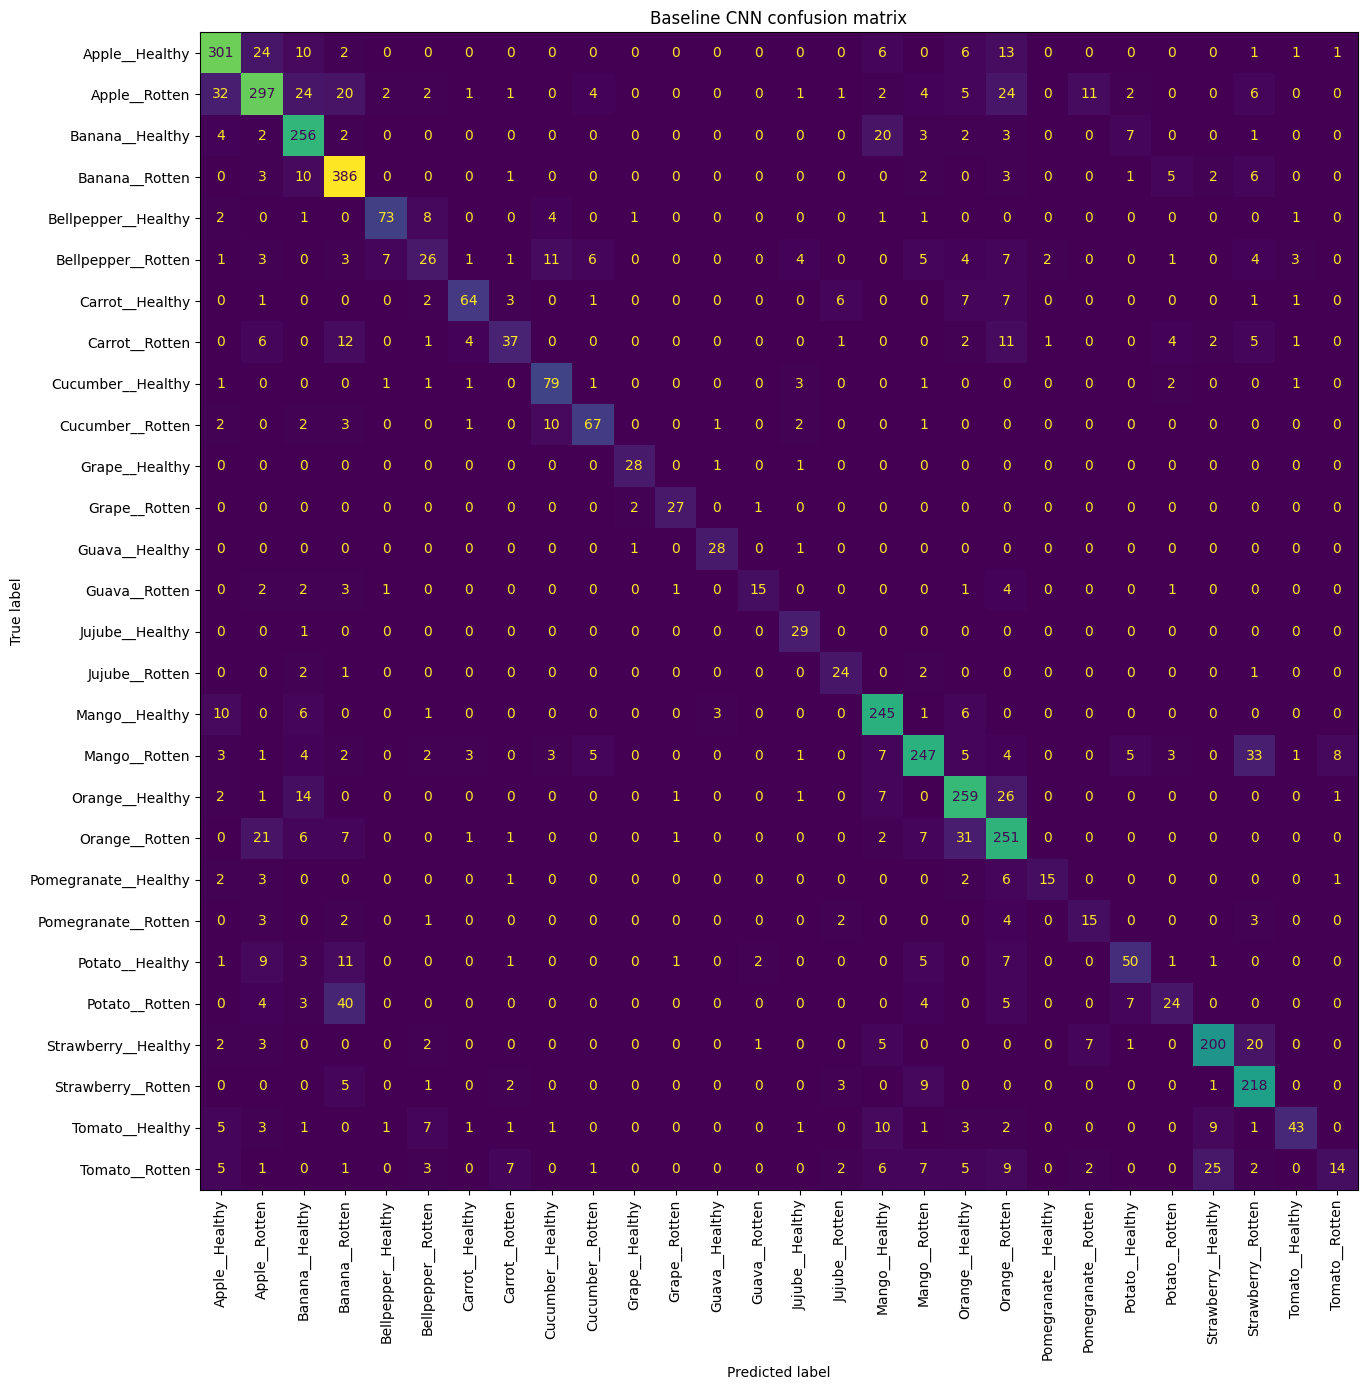

In [9]:
CM_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Baseline CNN confusion matrix")
plt.tight_layout()
plt.savefig(CM_DIR / "baseline_cnn_confusion_matrix.png", dpi=150)
plt.show()


## 9. Save baseline artifacts


In [10]:
final_model_path = MODELS_DIR / "best_model.keras"
model.save(final_model_path)

metadata = {
    "model_name": "baseline_cnn",
    "dataset": "muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten",
    "num_classes": NUM_CLASSES,
    "image_size": list(IMAGE_SIZE),
    "epochs_requested": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "metrics": {
        "test_accuracy": accuracy,
        "macro_f1": macro_f1,
    },
    "artifacts": {
        "final_model": str(final_model_path),
        "checkpoint": str(checkpoint_path),
        "training_curves": str(FIGURES_DIR / "baseline_cnn_training_curves.png"),
        "confusion_matrix": str(CM_DIR / "baseline_cnn_confusion_matrix.png"),
    },
}

with open(MODEL_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

report_df.to_csv(FIGURES_DIR / "baseline_cnn_classification_report.csv")

print("Saved model:", final_model_path)
print("Saved metadata:", MODEL_METADATA_PATH)


Saved model: D:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\models\best_model.keras
Saved metadata: D:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\models\model_metadata.json
